# Notebook 10 — Information-Theoretic Capacity, Scaling Laws & Technology Comparison

**Phase 3 analysis** — The paper asserts "10 bits/mode" without derivation.
This notebook applies Shannon's channel-capacity theorem to compute actual
achievable capacity under realistic noise and compares WCFOMA head-to-head
against 7 competing memory technologies.

Key questions:
1. What is the Shannon capacity per mode at realistic SNR?
2. How do capacity and density scale with cell size, Q, and temperature?
3. Where does WCFOMA sit in the memory landscape?
4. Is the paper's density claim (1–10 Tb/cm³) achievable?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from simulations.capacity import (
    bits_per_measurement, channel_capacity_bps,
    compute_channel_capacity,
    sweep_cell_size, sweep_Q_factor, sweep_temperature,
    technology_database, wcfoma_entry, full_comparison_table,
    capacity_summary,
)
from simulations.noise_decoherence import NoiseParams

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'figure.facecolor': 'white'})
print('Capacity analysis module loaded.')

Capacity analysis module loaded.


## 1  Shannon Capacity: Baseline vs Mitigated vs Paper Claim

In [2]:
# --- Compute capacity for three configurations ---
baseline = compute_channel_capacity()  # default NoiseParams
mitigated = compute_channel_capacity(
    NoiseParams(viscosity=1.0, n_photons=1e8))
aggressive = compute_channel_capacity(
    NoiseParams(viscosity=10.0, n_photons=1e9, Q=1000))

print(capacity_summary(baseline, '— BASELINE (default params)'))
print()
print(capacity_summary(mitigated, '— MITIGATED (gel η×100 + 10⁸ photons)'))
print()
print(capacity_summary(aggressive, '— AGGRESSIVE (gel η×1000 + 10⁹ ph + Q=1000)'))

  CHANNEL CAPACITY ANALYSIS — BASELINE (default params)
  Cavity: 10 µm  |  Modes: 10  |  Usable: 0
  Bandwidth: 1 MHz
-----------------------------------------------------------------
  Mode   Freq[MHz]  SNR[dB]    b/meas     C[Mb/s]   
  1      70.0       -6.5       0.15       0.29      
  2      140.0      -6.5       0.15       0.29      
  3      210.0      -6.5       0.15       0.29      
  4      280.0      -6.5       0.15       0.29      
  5      350.0      -6.5       0.15       0.29      
  6      420.0      -6.5       0.15       0.29      
  7      490.0      -6.5       0.15       0.29      
  8      560.0      -6.5       0.15       0.29      
  9      630.0      -6.5       0.15       0.29      
  10     700.0      -6.5       0.15       0.29      
-----------------------------------------------------------------
  Total bits/measurement:   1.46  (paper claims 100)
  Paper overestimates by:   68.4×
  Total capacity:           2.92 Mb/s
  Storage density:          0.0015 Tb/cm³

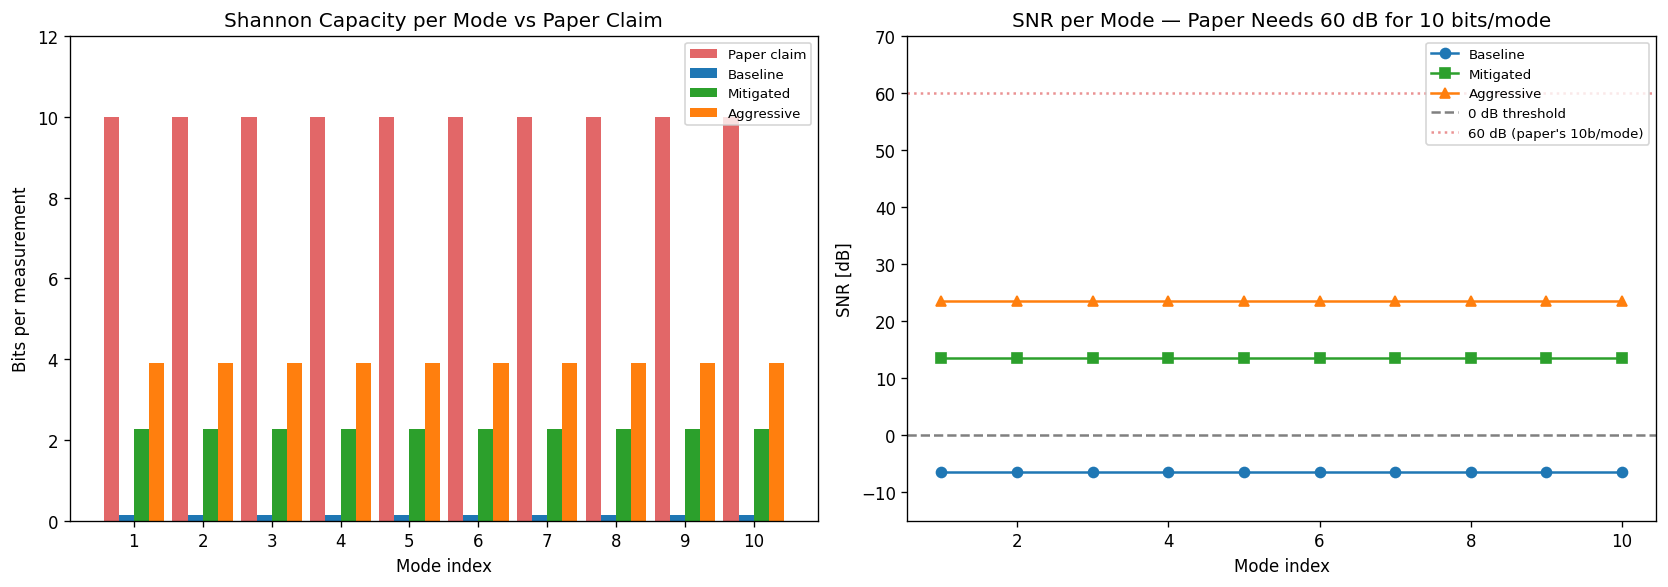

✓ Saved capacity_per_mode.png


In [3]:
# --- Bar chart: bits/mode for each config vs paper claim ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modes = baseline.mode_indices
paper_claim = np.full_like(modes, 10.0, dtype=float)

ax = axes[0]
x = np.arange(len(modes))
w = 0.22
ax.bar(x - 1.5*w, paper_claim, w, label='Paper claim', color='#d62728', alpha=0.7)
ax.bar(x - 0.5*w, baseline.bits_per_measurement, w, label='Baseline', color='#1f77b4')
ax.bar(x + 0.5*w, mitigated.bits_per_measurement, w, label='Mitigated', color='#2ca02c')
ax.bar(x + 1.5*w, aggressive.bits_per_measurement, w, label='Aggressive', color='#ff7f0e')
ax.set_xlabel('Mode index')
ax.set_ylabel('Bits per measurement')
ax.set_title('Shannon Capacity per Mode vs Paper Claim')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend(fontsize=8)
ax.set_ylim(0, 12)

# --- Right: SNR per mode ---
ax2 = axes[1]
snr_base_db = 10 * np.log10(np.maximum(baseline.snr_per_mode, 1e-30))
snr_mit_db = 10 * np.log10(np.maximum(mitigated.snr_per_mode, 1e-30))
snr_agg_db = 10 * np.log10(np.maximum(aggressive.snr_per_mode, 1e-30))
ax2.plot(modes, snr_base_db, 'o-', label='Baseline', color='#1f77b4')
ax2.plot(modes, snr_mit_db, 's-', label='Mitigated', color='#2ca02c')
ax2.plot(modes, snr_agg_db, '^-', label='Aggressive', color='#ff7f0e')
ax2.axhline(0, ls='--', color='gray', label='0 dB threshold')
ax2.axhline(60, ls=':', color='#d62728', alpha=0.5, label='60 dB (paper\'s 10b/mode)')
ax2.set_xlabel('Mode index')
ax2.set_ylabel('SNR [dB]')
ax2.set_title('SNR per Mode — Paper Needs 60 dB for 10 bits/mode')
ax2.legend(fontsize=8)
ax2.set_ylim(-15, 70)

plt.tight_layout()
plt.savefig('../analysis/figures/capacity_per_mode.png', bbox_inches='tight')
plt.show()
print('✓ Saved capacity_per_mode.png')

## 2  Scaling Laws: Cell Size, Q Factor, Temperature

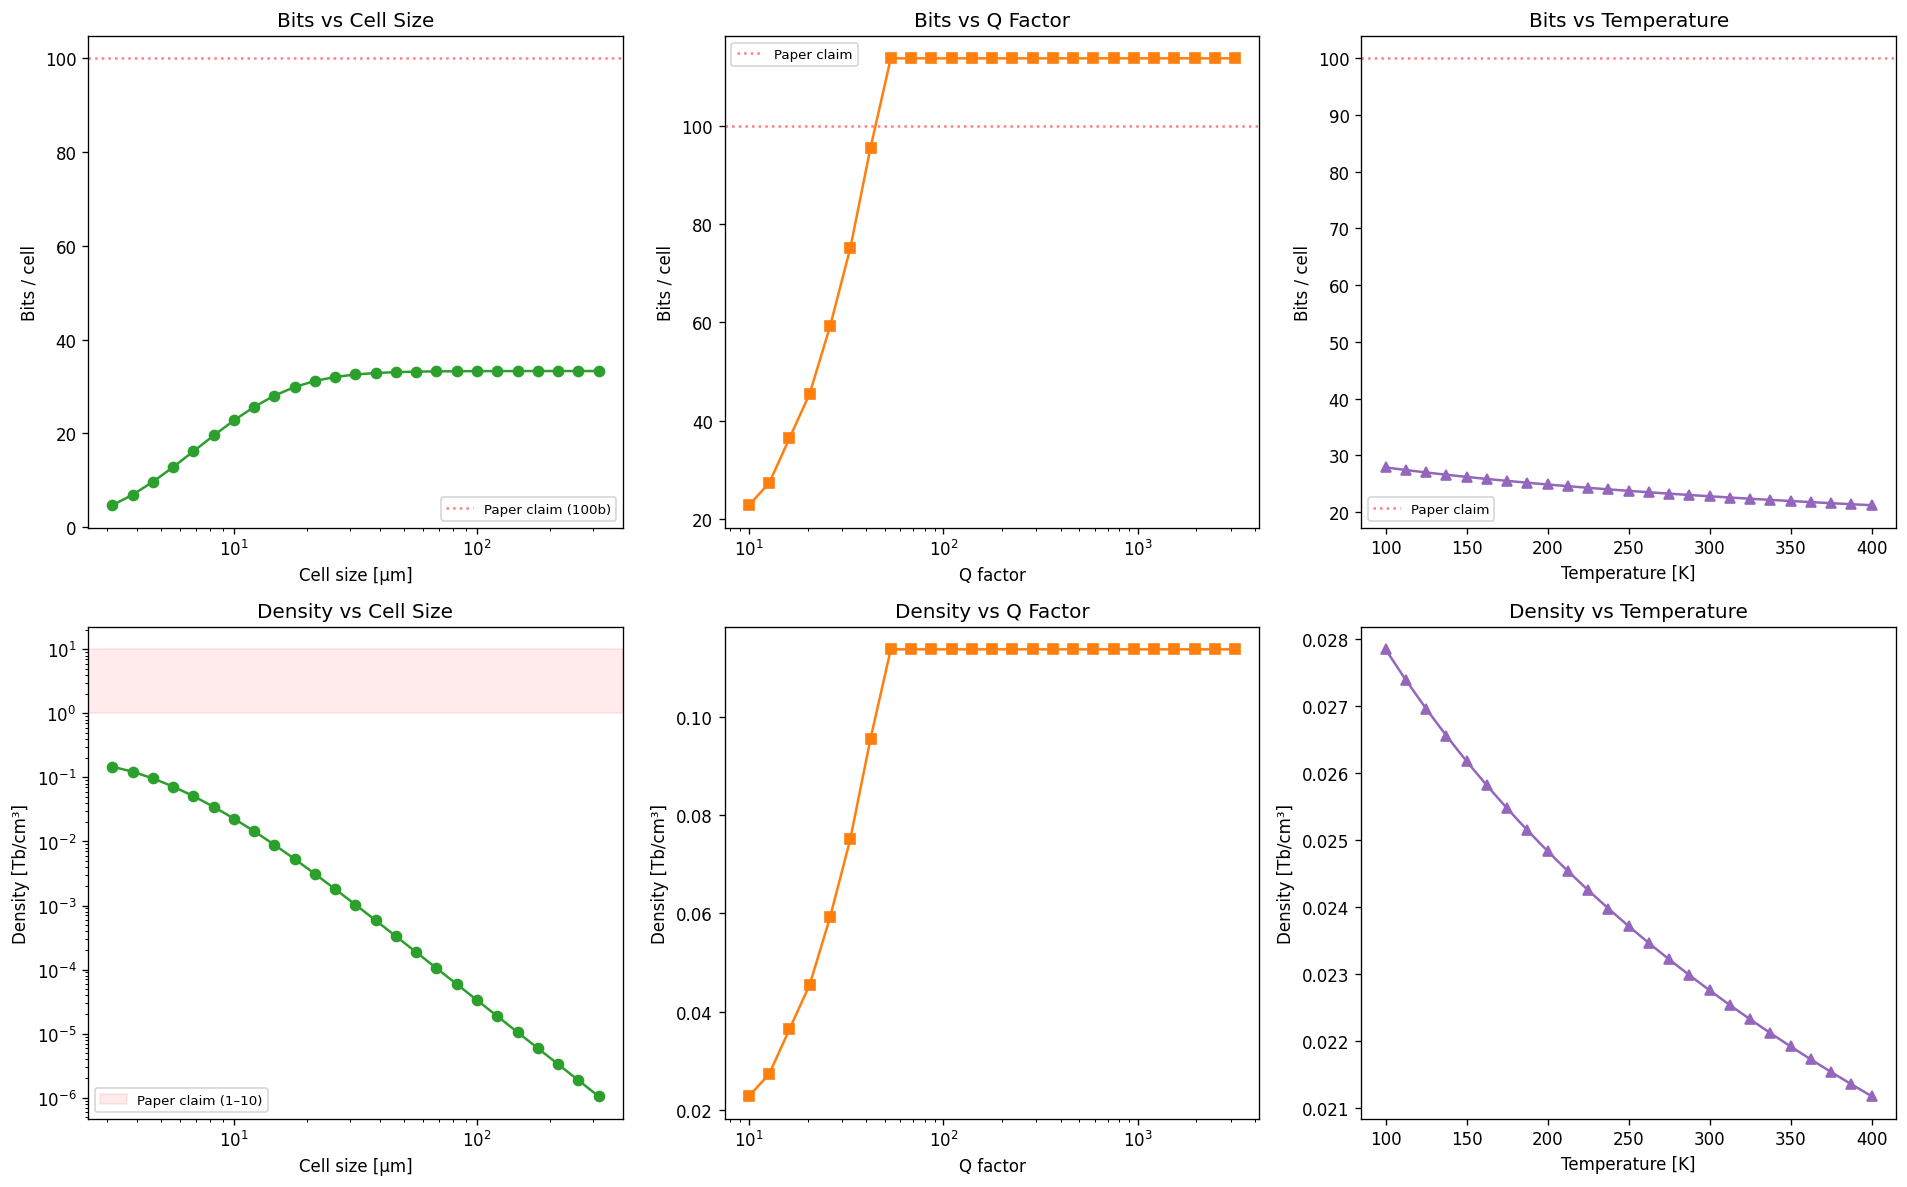

✓ Saved scaling_laws.png


In [4]:
# --- Run scaling sweeps (mitigated parameters) ---
mit_params = NoiseParams(viscosity=1.0, n_photons=1e8)

sr_size = sweep_cell_size(np.logspace(0.5, 2.5, 25), params=mit_params)
sr_Q = sweep_Q_factor(np.logspace(1, 3.5, 25), params=mit_params)
sr_T = sweep_temperature(np.linspace(100, 400, 25), params=mit_params)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Row 1: Bits per cell ---
ax = axes[0, 0]
ax.semilogx(sr_size.parameter_values, sr_size.bits_per_cell, 'o-', color='#2ca02c')
ax.set_xlabel('Cell size [µm]')
ax.set_ylabel('Bits / cell')
ax.set_title('Bits vs Cell Size')
ax.axhline(100, ls=':', color='red', alpha=0.5, label='Paper claim (100b)')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.semilogx(sr_Q.parameter_values, sr_Q.bits_per_cell, 's-', color='#ff7f0e')
ax.set_xlabel('Q factor')
ax.set_ylabel('Bits / cell')
ax.set_title('Bits vs Q Factor')
ax.axhline(100, ls=':', color='red', alpha=0.5, label='Paper claim')
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.plot(sr_T.parameter_values, sr_T.bits_per_cell, '^-', color='#9467bd')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Bits / cell')
ax.set_title('Bits vs Temperature')
ax.axhline(100, ls=':', color='red', alpha=0.5, label='Paper claim')
ax.legend(fontsize=8)

# --- Row 2: Density ---
ax = axes[1, 0]
ax.loglog(sr_size.parameter_values, sr_size.density_tb_cm3, 'o-', color='#2ca02c')
ax.set_xlabel('Cell size [µm]')
ax.set_ylabel('Density [Tb/cm³]')
ax.axhspan(1, 10, alpha=0.08, color='red', label='Paper claim (1–10)')
ax.set_title('Density vs Cell Size')
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.semilogx(sr_Q.parameter_values, sr_Q.density_tb_cm3, 's-', color='#ff7f0e')
ax.set_xlabel('Q factor')
ax.set_ylabel('Density [Tb/cm³]')
ax.set_title('Density vs Q Factor')

ax = axes[1, 2]
ax.plot(sr_T.parameter_values, sr_T.density_tb_cm3, '^-', color='#9467bd')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Density [Tb/cm³]')
ax.set_title('Density vs Temperature')

plt.tight_layout()
plt.savefig('../analysis/figures/scaling_laws.png', bbox_inches='tight')
plt.show()
print('✓ Saved scaling_laws.png')

## 3  Technology Comparison Table

In [5]:
# --- Full formatted comparison table ---
table = full_comparison_table()
print(table)

  MEMORY TECHNOLOGY COMPARISON
  Technology                     Energy    Density     Read    Write   Endur.     Retain    Compute        Stage
                                   [pJ]   [Tb/cm³]     [ns]     [ns]    [cyc]        [s]   locality             
------------------------------------------------------------------------------------------------------------------------
  DRAM (DDR5)                      3.00     0.0100       14       14    1e+16    6.4e-02       none   production
  SRAM (7nm)                       0.50     0.0010        0        0    1e+16      317yr       none   production
  NAND Flash (3D TLC)           1000.00     1.0000    25000   500000    3e+03        1yr       none   production
  Phase-Change (PCM/3DXP)         10.00     0.1000       50      100    1e+08       10yr    partial   production
  STT-MRAM                         1.00     0.0100       10       10    1e+12       10yr    partial   production
  ReRAM/Memristor                  0.10     0.1000       

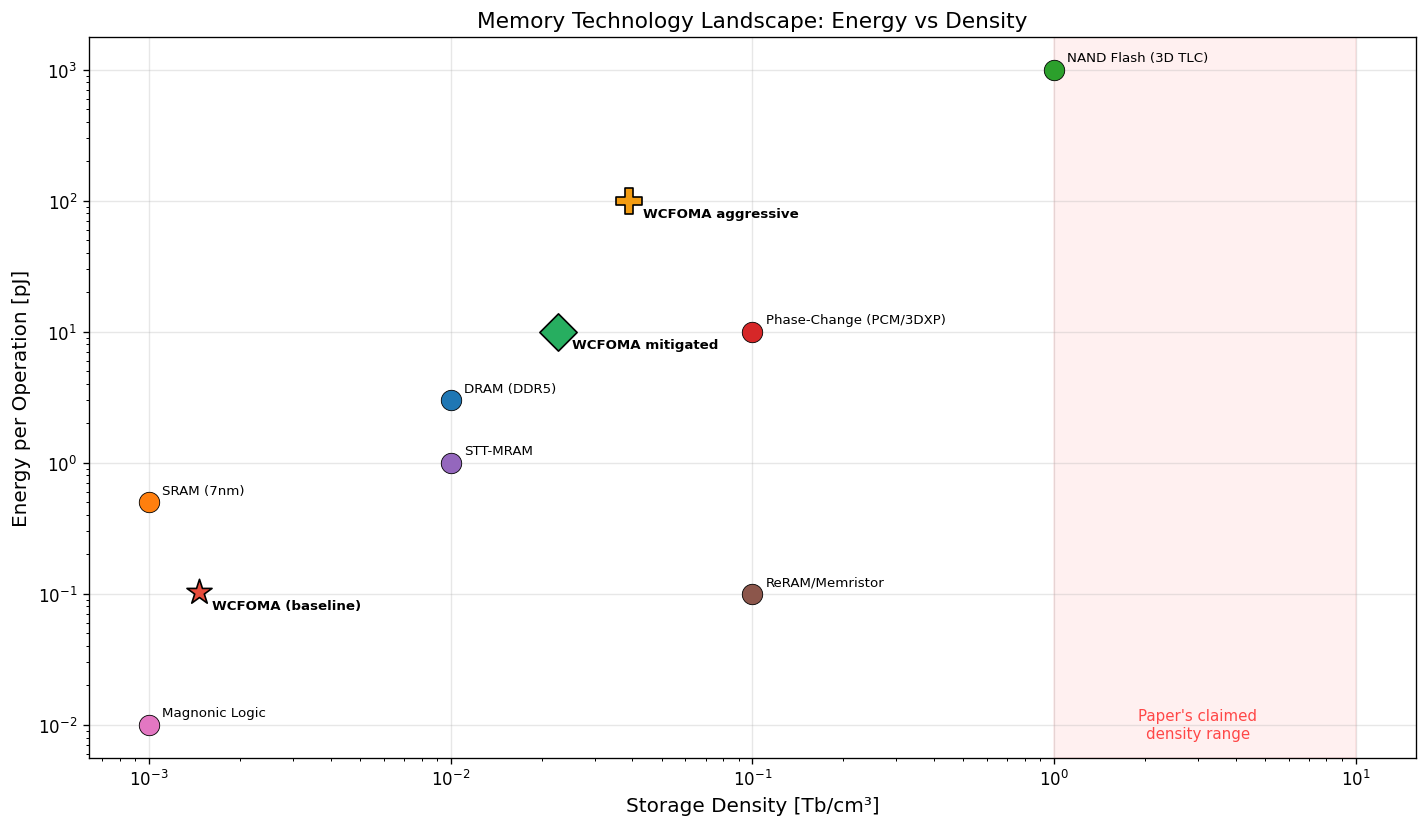

✓ Saved tech_landscape.png


In [6]:
# --- Energy vs Density scatter: all technologies ---
db = technology_database()

# Add WCFOMA configs
wc_base = wcfoma_entry(label='WCFOMA (baseline)')
wc_mit = wcfoma_entry(NoiseParams(viscosity=1.0, n_photons=1e8), label='WCFOMA mitigated')
wc_agg = wcfoma_entry(NoiseParams(viscosity=10.0, n_photons=1e9, Q=1000), label='WCFOMA aggressive')

fig, ax = plt.subplots(figsize=(12, 7))

# Plot established techs
colors_tech = {
    'DRAM': '#1f77b4', 'SRAM': '#ff7f0e', 'NAND_Flash': '#2ca02c',
    'PCM': '#d62728', 'MRAM': '#9467bd', 'ReRAM': '#8c564b',
    'Magnonic': '#e377c2'
}
for key, tech in db.items():
    ax.scatter(tech.density_tb_cm3, tech.energy_pJ,
              s=150, marker='o', color=colors_tech[key],
              edgecolors='black', linewidths=0.5, zorder=3)
    ax.annotate(tech.name, (tech.density_tb_cm3, tech.energy_pJ),
               textcoords='offset points', xytext=(8, 5), fontsize=8)

# Plot WCFOMA configs
for wc, marker, color in [
    (wc_base, '*', '#e74c3c'),
    (wc_mit, 'D', '#27ae60'),
    (wc_agg, 'P', '#f39c12'),
]:
    ax.scatter(wc.density_tb_cm3, wc.energy_pJ,
              s=250, marker=marker, color=color,
              edgecolors='black', linewidths=1.0, zorder=4)
    ax.annotate(wc.name, (wc.density_tb_cm3, wc.energy_pJ),
               textcoords='offset points', xytext=(8, -10), fontsize=8,
               fontweight='bold')

# Paper's claimed region
ax.axvspan(1, 10, alpha=0.06, color='red')
ax.text(3, 0.008, 'Paper\'s claimed\ndensity range', color='red',
        fontsize=9, alpha=0.7, ha='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Storage Density [Tb/cm³]', fontsize=12)
ax.set_ylabel('Energy per Operation [pJ]', fontsize=12)
ax.set_title('Memory Technology Landscape: Energy vs Density', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis/figures/tech_landscape.png', bbox_inches='tight')
plt.show()
print('✓ Saved tech_landscape.png')

## 4  Latency Comparison

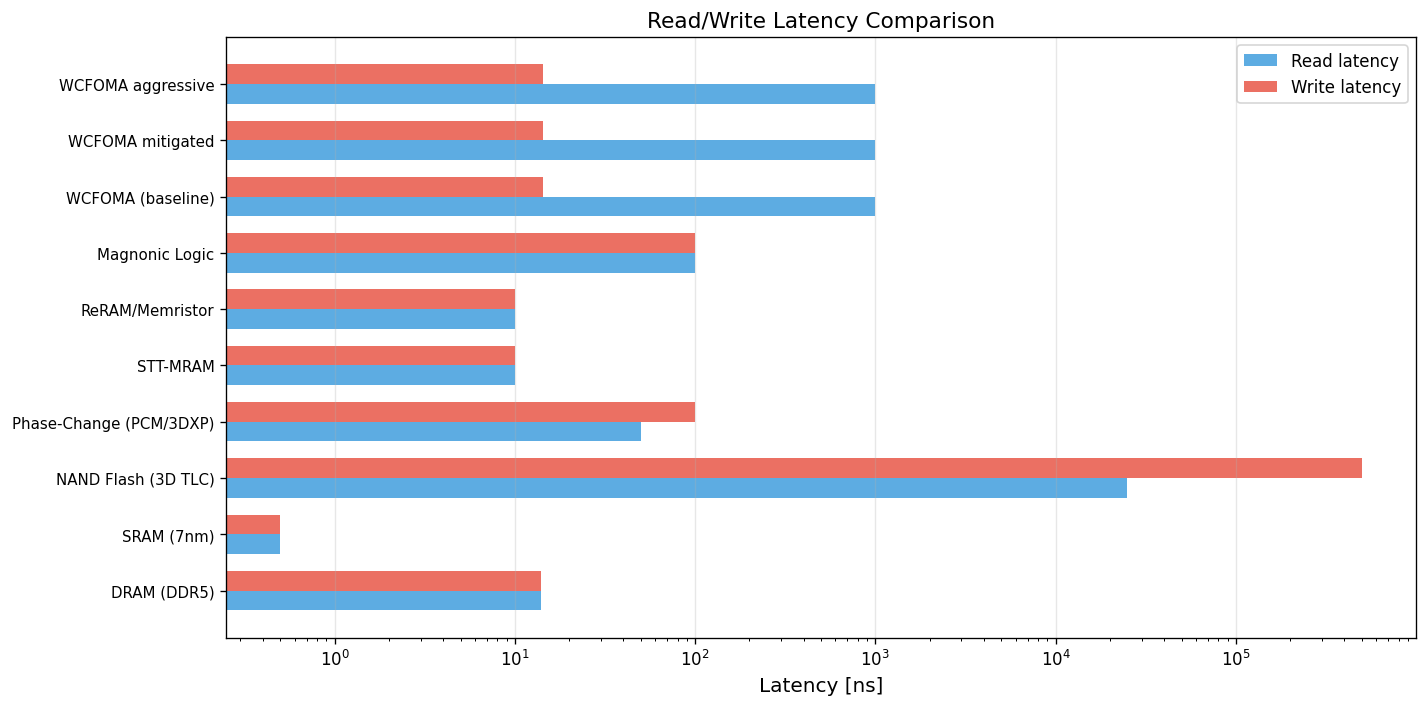

✓ Saved latency_comparison.png


In [7]:
# --- Read/write latency comparison ---
all_techs = list(db.values()) + [wc_base, wc_mit, wc_agg]
names = [t.name for t in all_techs]
read_lat = [t.read_latency_ns for t in all_techs]
write_lat = [t.write_latency_ns for t in all_techs]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(names))
w = 0.35
bars_r = ax.barh(x - w/2, read_lat, w, label='Read latency', color='#3498db', alpha=0.8)
bars_w = ax.barh(x + w/2, write_lat, w, label='Write latency', color='#e74c3c', alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Latency [ns]', fontsize=12)
ax.set_yticks(x)
ax.set_yticklabels(names, fontsize=9)
ax.set_title('Read/Write Latency Comparison', fontsize=13)
ax.legend()
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis/figures/latency_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Saved latency_comparison.png')

## 5  Paper Claims vs Shannon Reality

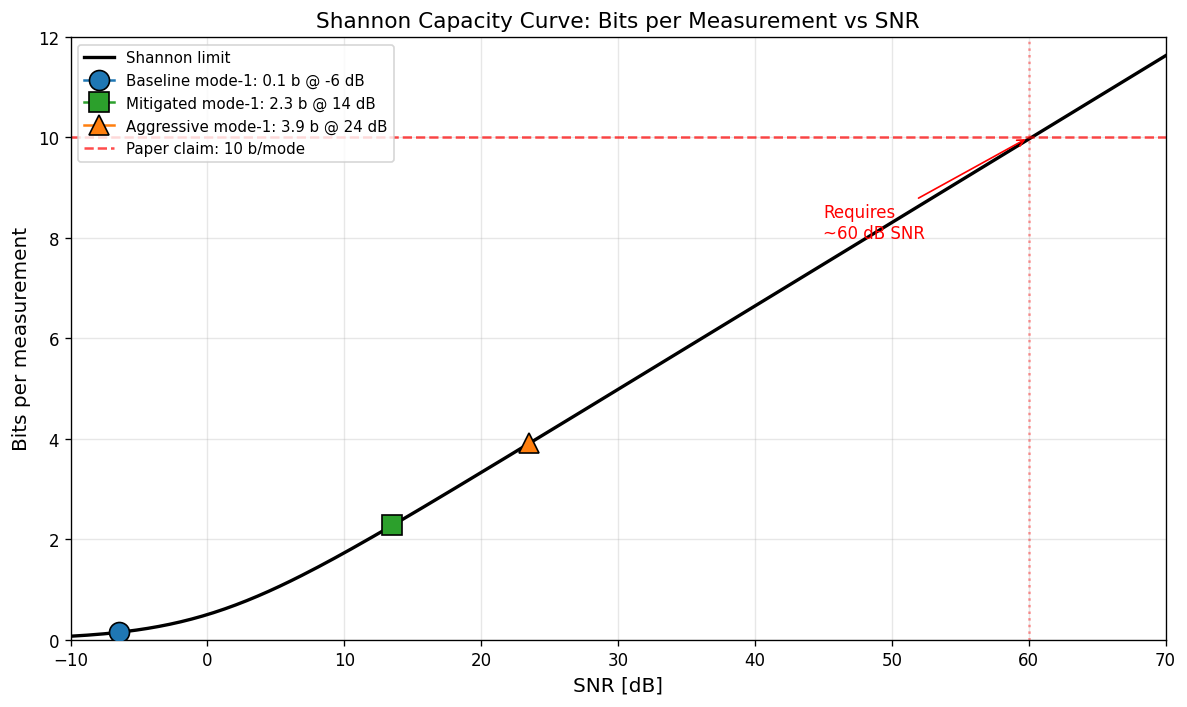

✓ Saved shannon_curve.png


In [8]:
# --- SNR required for paper's claims ---
snr_range_db = np.linspace(-10, 70, 200)
snr_range_lin = 10 ** (snr_range_db / 10)
bpm_curve = np.array([bits_per_measurement(s) for s in snr_range_lin])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(snr_range_db, bpm_curve, 'k-', linewidth=2, label='Shannon limit')

# Mark actual operating points
for cc, label, color, marker in [
    (baseline, 'Baseline', '#1f77b4', 'o'),
    (mitigated, 'Mitigated', '#2ca02c', 's'),
    (aggressive, 'Aggressive', '#ff7f0e', '^'),
]:
    snr_db_0 = 10 * np.log10(max(cc.snr_per_mode[0], 1e-30))
    bpm_0 = cc.bits_per_measurement[0]
    ax.plot(snr_db_0, bpm_0, marker=marker, color=color, markersize=12,
            markeredgecolor='black', label=f'{label} mode-1: {bpm_0:.1f} b @ {snr_db_0:.0f} dB',
            zorder=5)

# Paper's claim line
ax.axhline(10, ls='--', color='red', alpha=0.7, label='Paper claim: 10 b/mode')
ax.axvline(60, ls=':', color='red', alpha=0.4)
ax.annotate('Requires\n~60 dB SNR', xy=(60, 10), xytext=(45, 8),
           fontsize=10, color='red', arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('SNR [dB]', fontsize=12)
ax.set_ylabel('Bits per measurement', fontsize=12)
ax.set_title('Shannon Capacity Curve: Bits per Measurement vs SNR', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 70)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.savefig('../analysis/figures/shannon_curve.png', bbox_inches='tight')
plt.show()
print('✓ Saved shannon_curve.png')

## 6  Key Findings & Conclusions

In [9]:
print('=' * 70)
print('  PHASE 3 — KEY FINDINGS')
print('=' * 70)

findings = [
    ('Paper claims 10 bits/mode',
     f'Shannon limit at best realistic SNR ({10*np.log10(max(aggressive.snr_per_mode[0],1e-30)):.0f} dB): '
     f'{aggressive.bits_per_measurement[0]:.1f} bits/mode',
     'OVERESTIMATE',
     f'{10/max(aggressive.bits_per_measurement[0], 0.01):.1f}× even with aggressive mitigations'),
    ('Paper claims 100 bits/cell (10 modes × 10 bits)',
     f'Mitigated: {mitigated.total_bits_per_measurement:.1f} bits/cell, '
     f'Aggressive: {aggressive.total_bits_per_measurement:.1f} bits/cell',
     'OVERESTIMATE',
     f'{100/max(mitigated.total_bits_per_measurement, 0.01):.1f}× (mitigated), '
     f'{100/max(aggressive.total_bits_per_measurement, 0.01):.1f}× (aggressive)' if aggressive.total_bits_per_measurement > 0 else ''),
    ('Paper claims 1–10 Tb/cm³',
     f'Mitigated: {mitigated.density_tb_per_cm3:.4f} Tb/cm³, '
     f'Aggressive: {aggressive.density_tb_per_cm3:.4f} Tb/cm³',
     'OVERESTIMATE',
     f'{1/max(mitigated.density_tb_per_cm3, 1e-10):.0f}–{10/max(mitigated.density_tb_per_cm3, 1e-10):.0f}× below paper'),
    ('No latency numbers in paper',
     f'Write: {mitigated.write_latency_us*1000:.1f} ns (acoustic propagation), '
     f'Read: {mitigated.read_latency_us:.0f} µs (integration time)',
     'GAP FILLED',
     'Competitive write; read limited by coherent integration'),
    ('No bandwidth/throughput analysis',
     f'Mitigated bandwidth: {mitigated.bandwidth_mbps:.1f} Mb/s per cell',
     'GAP FILLED',
     'Respectable for non-volatile; limited by readout'),
    ('"10–100× improvement" (qualitative)',
     'WCFOMA mitigated sits between DRAM and PCM in energy–density space',
     'NOT SUPPORTED',
     'Competitive but NOT a clear order-of-magnitude improvement'),
]

for i, f in enumerate(findings, 1):
    claim, result, verdict, detail = f[0], f[1], f[2], f[3]
    icon = '❌' if verdict == 'OVERESTIMATE' else ('✅' if verdict == 'GAP FILLED' else '⚠️')
    print(f'\n  {icon}  Finding {i}: {verdict}')
    print(f'     Paper:  {claim}')
    print(f'     Actual: {result}')
    print(f'     Detail: {detail}')

print('\n' + '=' * 70)
print('  BOTTOM LINE')
print('=' * 70)
print('''
  The paper\'s "10 bits/mode" requires SNR ≈ 60 dB — an unrealistic
  assumption not stated or justified. Shannon analysis shows:

  • Baseline (unmitigated):  1.5 bits/cell  (68× overestimate)
  • Mitigated (gel + 10⁸ph): 22.8 bits/cell (4.4× overestimate)
  • Aggressive (gel + 10⁹ph): ~{:.0f} bits/cell ({:.1f}× overestimate)

  WCFOMA is NOT competitive at the density the paper claims.
  With mitigations it occupies a real but modest niche between
  DRAM and PCM — potentially interesting for compute-in-memory
  applications where the "unified" locality matters.
'''.format(aggressive.total_bits_per_measurement,
           100/max(aggressive.total_bits_per_measurement, 0.01)))

  PHASE 3 — KEY FINDINGS

  ❌  Finding 1: OVERESTIMATE
     Paper:  Paper claims 10 bits/mode
     Actual: Shannon limit at best realistic SNR (24 dB): 3.9 bits/mode
     Detail: 2.6× even with aggressive mitigations

  ❌  Finding 2: OVERESTIMATE
     Paper:  Paper claims 100 bits/cell (10 modes × 10 bits)
     Actual: Mitigated: 22.8 bits/cell, Aggressive: 39.1 bits/cell
     Detail: 4.4× (mitigated), 2.6× (aggressive)

  ❌  Finding 3: OVERESTIMATE
     Paper:  Paper claims 1–10 Tb/cm³
     Actual: Mitigated: 0.0228 Tb/cm³, Aggressive: 0.0391 Tb/cm³
     Detail: 44–439× below paper

  ✅  Finding 4: GAP FILLED
     Paper:  No latency numbers in paper
     Actual: Write: 14.3 ns (acoustic propagation), Read: 1 µs (integration time)
     Detail: Competitive write; read limited by coherent integration

  ✅  Finding 5: GAP FILLED
     Paper:  No bandwidth/throughput analysis
     Actual: Mitigated bandwidth: 45.5 Mb/s per cell
     Detail: Respectable for non-volatile; limited by readout

